In [5]:
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.load_tex_defs()

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

ModuleNotFoundError: No module named 'bayesian_stats_course_tools'

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
print(np.pi)

3.141592653589793


In [21]:
def pi_anal_arr(n):
    ks = np.arange(0, n)
    terms = 4 * (-1)** ks /(2 * ks + 1)

    ys = np.zeros_like(ks)

    for k in ks:
        if k == 0:
            continue
        else:
            terms[k] += terms[k-1]

    return ks, terms

    

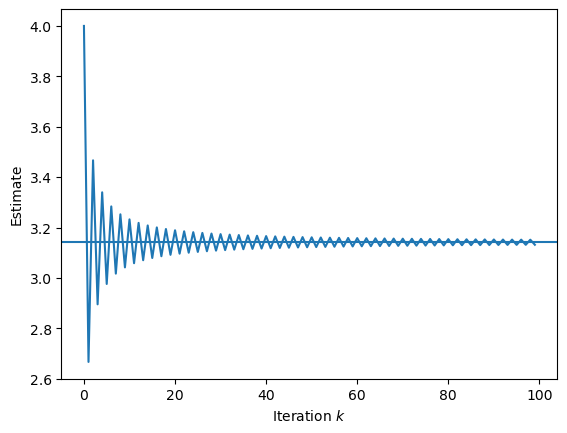

In [35]:
fig, ax = plt.subplots()

ax.set_xlabel("Iteration $k$")
ax.set_ylabel("Estimate")


ax.axhline(np.pi)
ax.plot(*pi_anal_arr(100))

In [78]:
def sq_samples(N, R):
    return np.random.uniform(-R, R, size=N), np.random.uniform(-R, R, size=N)

$\frac{n_{<r}}{n}= \frac{\pi r^2}{4 r^2}\implies \pi \approx 4 \frac{n_{<r}}{n}$

In [107]:
def pi_est(N):
    samples_x, samples_y = sq_samples(N, 1)
    dist = np.sqrt(samples_x**2 + samples_y**2)

    in_circ = (dist <= 1)
    
    return 4 * np.sum(in_circ) / N
    

In [116]:
fig, ax = plt.subplots()

n = 1000

ax.set_xlabel("Iteration $k$")
ax.set_ylabel("Estimate")

ks = np.arange(1, n)
ys = [pi_est(k) for k in ks]

ax.axhline(np.pi)
ax.plot(ks, ys)

In [141]:
N = 1000

ks, ys_anal = pi_anal_arr(N)
ys_circ = np.array([pi_est(k) for k in ks])


In [151]:
fig, ax = plt.subplots(figsize=(6,4), sharex=True)

ax.set_xlabel("Iteration ($k$)")
ax.set_ylabel("$|\\hat{\\pi} - \\pi|$")

ax.axhline(0, ls='--', c='r')

ax.scatter(ks, np.abs(ys_anal - np.pi), s=1, label="Analytic")
ax.scatter(ks, np.abs(ys_circ - np.pi), s=1, label="Monte Carlo")

ax.set_yscale('log')

ax.legend()